# 🧱 Multiíndices
## También conocidos como índices jerárquicos

📥 **Importamos la librería `pandas`** para trabajar con datos tabulares.

In [1]:
import pandas as pd

📄 **Cargamos el archivo CSV** que contiene los datos de acciones de automóviles.

In [2]:
carstocks = pd.read_csv("data/car_stocks.csv")

In [3]:
titanic = pd.read_csv("data/titanic.csv")
titanic['age'] = titanic["age"].replace(['?'], [None]).astype('float')
titanic['fare'] = titanic["fare"].replace(['?'], [None]).astype('float')

📈 **Agrupamos por niveles del índice** y calculamos promedios con `groupby()` y `mean(numeric_only=True)`.

🔹 **`titanic.groupby("sex")`**
Agrupa los datos del DataFrame `titanic` según la columna `"sex"` (por ejemplo: *male* y *female*).

🔹 **`["age"]`**
Después de agrupar, selecciona únicamente la columna `"age"` para trabajar solo con las edades.

🔹 **`.mean(numeric_only=True)`**
Calcula el **promedio** de la edad en cada grupo.
El parámetro `numeric_only=True` indica que solo se consideren columnas numéricas (en este caso, la edad).

🔹 **Resultado**
Se obtiene una **Serie** (`s1`) que contiene la edad promedio de hombres y mujeres por separado.

👉 En resumen:
El código calcula la **edad promedio de los pasajeros del Titanic según su sexo**.

In [4]:
s1 = titanic.groupby("sex")["age"].mean(numeric_only=True)

### 📌 ¿Qué hace `s1.index`?

`s1.index` devuelve los valores del índice de la Serie `s1`.

Recordemos que `s1` se creó así:

`s1 = titanic.groupby("sex")["age"].mean(numeric_only=True)`

Como se agrupó por la columna `"sex"`, el índice de `s1` está formado por las categorías de esa columna (por ejemplo: `female` y `male`).

Por lo tanto, al ejecutar `s1.index` se obtiene algo como:

`Index(['female', 'male'], dtype='object', name='sex')`

👉 En resumen:
`s1.index` muestra los valores que se usaron para agrupar, es decir, los tipos de sexo presentes en el DataFrame.

In [5]:
s1.index

Index(['female', 'male'], dtype='object', name='sex')

## Grouping By Multiple Columns!

In [6]:
df = titanic.groupby(["pclass", "sex"])["age"].mean(numeric_only=True)
df

pclass  sex   
1       female    37.037594
        male      41.029250
2       female    27.499191
        male      30.815401
3       female    22.185307
        male      25.962273
Name: age, dtype: float64

### 📊 Explicación del código

`df = titanic.groupby(["pclass", "sex"]).mean(numeric_only=True)`

🔹 **`groupby(["pclass", "sex"])`**
Agrupa el DataFrame `titanic` usando **dos columnas al mismo tiempo**:
- `pclass` (clase del pasajero: 1, 2 o 3)
- `sex` (male o female)

Esto significa que se crean grupos como:
- (1, female)
- (1, male)
- (2, female)
- (2, male)
- etc.

🔹 **`.mean(numeric_only=True)`**
Calcula el **promedio de todas las columnas numéricas** dentro de cada grupo (por ejemplo: edad, tarifa, etc.).

🔹 **Resultado**
Se obtiene un nuevo DataFrame (`df`) donde:
- El índice es múltiple (MultiIndex) formado por `pclass` y `sex`.
- Las columnas contienen los promedios de las variables numéricas para cada combinación de clase y sexo.

👉 En resumen:
El código calcula los **promedios de las columnas numéricas del Titanic agrupando por clase y sexo al mismo tiempo**.

In [7]:
df = titanic.groupby(["pclass", "sex"]).mean(numeric_only=True)
df

survived        age     sibsp     parch        fare
pclass sex                                                        
1      female  0.965278  37.037594  0.555556  0.472222  109.412385
       male    0.340782  41.029250  0.340782  0.279330   69.888385
2      female  0.886792  27.499191  0.500000  0.650943   23.234827
       male    0.146199  30.815401  0.327485  0.192982   19.904946
3      female  0.490741  22.185307  0.791667  0.731481   15.324250
       male    0.152130  25.962273  0.470588  0.255578   12.415462

In [8]:
df.index

MultiIndex([(1, 'female'),
            (1,   'male'),
            (2, 'female'),
            (2,   'male'),
            (3, 'female'),
            (3,   'male')],
           names=['pclass', 'sex'])

In [9]:
titanic.index

RangeIndex(start=0, stop=1309, step=1)

In [10]:
df

survived        age     sibsp     parch        fare
pclass sex                                                        
1      female  0.965278  37.037594  0.555556  0.472222  109.412385
       male    0.340782  41.029250  0.340782  0.279330   69.888385
2      female  0.886792  27.499191  0.500000  0.650943   23.234827
       male    0.146199  30.815401  0.327485  0.192982   19.904946
3      female  0.490741  22.185307  0.791667  0.731481   15.324250
       male    0.152130  25.962273  0.470588  0.255578   12.415462

### 📊 Explicación del código

`titanic.groupby(["sex", "age"]).mean(numeric_only=True)`

🔹 **`groupby(["sex", "age"])`**
Agrupa el DataFrame `titanic` usando dos columnas:
- `sex`
- `age`

Esto significa que se crea un grupo por **cada combinación exacta de sexo y edad**.
Por ejemplo:
- (female, 18)
- (male, 30)
- (female, 25)
- etc.

🔹 **`.mean(numeric_only=True)`**
Calcula el promedio de todas las columnas numéricas dentro de cada grupo.

⚠️ Importante:
Como la edad suele tener muchos valores distintos, este agrupamiento puede generar **muchísimos grupos**, incluso uno por persona si las edades no se repiten.

🔹 **Resultado**
Se obtiene un DataFrame con un **índice múltiple (MultiIndex)** formado por `sex` y `age`, y como columnas los promedios de las variables numéricas.

👉 En resumen:
El código calcula los promedios de las columnas numéricas para cada combinación específica de sexo y edad.

In [11]:
titanic.groupby(["sex", "age"]).mean(numeric_only=True)

pclass  survived     sibsp     parch       fare
sex    age                                                       
female 0.1667   3.000000  1.000000  1.000000  2.000000  20.575000
       0.7500   3.000000  1.000000  2.000000  1.000000  19.258300
       0.9167   2.000000  1.000000  1.000000  2.000000  27.750000
       1.0000   2.800000  0.800000  0.800000  1.400000  19.467500
       2.0000   2.571429  0.285714  1.428571  1.428571  39.955357
...                  ...       ...       ...       ...        ...
male   70.0000  1.500000  0.000000  0.500000  0.500000  40.750000
       70.5000  3.000000  0.000000  0.000000  0.000000   7.750000
       71.0000  1.000000  0.000000  0.000000  0.000000  42.079200
       74.0000  3.000000  0.000000  0.000000  0.000000   7.775000
       80.0000  1.000000  1.000000  0.000000  0.000000  30.000000

[166 rows x 5 columns]

## Creating Your Own MultiIndex

In [12]:
pops = pd.read_csv("data/state_pops.csv")

In [13]:
pops.index

RangeIndex(start=0, stop=1272, step=1)

In [14]:
pops.set_index("state")

,year,population
state,,
AL,2012,4817528.0
AL,2010,4785570.0
AL,2011,4801627.0
AL,2009,4757938.0
AL,2013,4833722.0
...,...,...
USA,2013,316128839.0
USA,2009,306771529.0
USA,2010,309326295.0


In [15]:
pops.set_index("year")

,state,population
year,,
2012,AL,4817528.0
2010,AL,4785570.0
2011,AL,4801627.0
2009,AL,4757938.0
2013,AL,4833722.0
...,...,...
2013,USA,316128839.0
2009,USA,306771529.0
2010,USA,309326295.0


### 📌 Explicación del código

`pops.set_index(["state", "year"])`

🔹 **`set_index()`**
Este método cambia el índice del DataFrame.

🔹 **`["state", "year"]`**
Indica que ahora el índice estará formado por **dos columnas al mismo tiempo**:
- `state`
- `year`

Esto crea un **índice múltiple (MultiIndex)**, donde cada fila queda identificada por la combinación de estado y año.

📌 Ejemplo conceptual del resultado:

| state | year | population |
|-------|------|------------|
| CA    | 2020 | ...        |
| CA    | 2021 | ...        |
| TX    | 2020 | ...        |

Después de aplicar `set_index`, el índice sería: (state, year)


In [16]:
pops.set_index(["state", "year"])

population
state year             
AL    2012    4817528.0
      2010    4785570.0
      2011    4801627.0
      2009    4757938.0
      2013    4833722.0
...                 ...
USA   2013  316128839.0
      2009  306771529.0
      2010  309326295.0
      2011  311582564.0
      2012  313873685.0

[1272 rows x 1 columns]

### 📌 Explicación del código

`pops.set_index(["year", "state"])`

🔹 **`set_index()`** cambia el índice del DataFrame.

🔹 Al pasar `["year", "state"]`, se crea un **índice múltiple (MultiIndex)** donde:

1. El primer nivel del índice es `year`.
2. El segundo nivel del índice es `state`.

📌 Esto significa que ahora cada fila queda identificada primero por el año y luego por el estado.

La diferencia con `["state", "year"]` es el **orden jerárquico del índice**, lo cual afecta cómo se organizan y consultan los datos.

👉 En resumen:
El código convierte `year` y `state` en un índice jerárquico donde el año es el nivel principal y el estado el secundario.

In [17]:
pops.set_index(["year", "state"])

population
year state             
2012 AL       4817528.0
2010 AL       4785570.0
2011 AL       4801627.0
2009 AL       4757938.0
2013 AL       4833722.0
...                 ...
     USA    316128839.0
2009 USA    306771529.0
2010 USA    309326295.0
2011 USA    311582564.0
2012 USA    313873685.0

[1272 rows x 1 columns]

### 📌 Explicación del código

`pops.set_index(["state", "year"], inplace=True)`

🔹 **`set_index(["state", "year"])`**
Convierte las columnas `state` y `year` en un **índice múltiple (MultiIndex)**.
Cada fila quedará identificada por la combinación de estado y año.

🔹 **`inplace=True`**
Hace que el cambio se aplique directamente al DataFrame `pops`, sin necesidad de guardarlo en otra variable.
Es decir, modifica el DataFrame original.

⚠️ Sin `inplace=True`, tendrías que hacer algo como:
`pops = pops.set_index(["state", "year"])`

👉 En resumen:
El código establece un índice jerárquico con `state` y `year`, y modifica el DataFrame original directamente.

In [18]:
pops.set_index(["state", "year"], inplace=True)

In [19]:
pops

population
state year             
AL    2012    4817528.0
      2010    4785570.0
      2011    4801627.0
      2009    4757938.0
      2013    4833722.0
...                 ...
USA   2013  316128839.0
      2009  306771529.0
      2010  309326295.0
      2011  311582564.0
      2012  313873685.0

[1272 rows x 1 columns]

## Sorting A MultiIndex

### 📌 Explicación del código

`pops.sort_index()`

🔹 **`sort_index()`**
Ordena el DataFrame según su **índice**.

Si `pops` tiene un índice normal, lo ordenará de menor a mayor.
Si tiene un **MultiIndex** (por ejemplo, `state` y `year`), ordenará respetando la jerarquía del índice:

1. Primero ordena por el primer nivel.
2. Luego por el segundo nivel dentro de cada grupo.

⚠️ Importante:
Este método **no modifica el DataFrame original** a menos que uses:
`pops.sort_index(inplace=True)`

👉 En resumen:
El código ordena el DataFrame según su índice.

In [20]:
pops.sort_index()

population
state year            
AK    1990    553290.0
      1991    570193.0
      1992    588736.0
      1993    599434.0
      1994    603308.0
...                ...
WY    2009    559851.0
      2010    564222.0
      2011    567329.0
      2012    576626.0
      2013    582658.0

[1272 rows x 1 columns]

### 📌 Explicación del código

`pops.sort_index(ascending=False)`

🔹 **`sort_index()`**
Ordena el DataFrame según su índice.

🔹 **`ascending=False`**
Indica que el orden será **descendente** (de mayor a menor).

Si el DataFrame tiene un **MultiIndex** (por ejemplo, `state` y `year`), el orden descendente se aplicará respetando la jerarquía:
1. Primero se ordena el primer nivel del índice en orden descendente.
2. Luego el segundo nivel también en orden descendente dentro de cada grupo.

⚠️ Este método no modifica el DataFrame original a menos que se use `inplace=True`.

👉 En resumen:
Ordena el DataFrame por su índice, pero de forma descendente.

In [21]:
pops.sort_index(ascending=False)

population
state year            
WY    2013    582658.0
      2012    576626.0
      2011    567329.0
      2010    564222.0
      2009    559851.0
...                ...
AK    1994    603308.0
      1993    599434.0
      1992    588736.0
      1991    570193.0
      1990    553290.0

[1272 rows x 1 columns]

### 📌 Explicación del código

`pops.sort_index(level=1)`

🔹 **`sort_index()`**
Ordena el DataFrame según su índice.

🔹 **`level=1`**
Indica que se ordenará específicamente por el **segundo nivel del índice** (porque los niveles empiezan en 0).

Si `pops` tiene un **MultiIndex** como por ejemplo:
- Nivel 0 → `state`
- Nivel 1 → `year`

Entonces `level=1` ordenará según `year`, manteniendo la estructura del índice múltiple.

⚠️ No modifica el DataFrame original a menos que se use `inplace=True`.

👉 En resumen:
Ordena el DataFrame usando únicamente el segundo nivel del índice.

In [22]:
pops.sort_index(level=1)

,,population
state,year,
AK,1990,553290.0
AL,1990,4050055.0
AR,1990,2356586.0
AZ,1990,3684097.0
CA,1990,29959515.0
...,...,...
VT,2013,626630.0
WA,2013,6971406.0
WI,2013,5742713.0


### 📌 Explicación del código

`pops.sort_index(level=[1,0], ascending=[False,True])`

🔹 **`level=[1,0]`**
Indica que el ordenamiento se hará usando **dos niveles del índice**, pero en este orden:
1. Primero el nivel 1
2. Luego el nivel 0

Recuerda que en un `MultiIndex` los niveles comienzan en 0.

🔹 **`ascending=[False, True]`**
Define el tipo de orden para cada nivel:
- `False` → el nivel 1 se ordena **descendente**
- `True` → el nivel 0 se ordena **ascendente**

📌 En un ejemplo donde:
- Nivel 0 = `state`
- Nivel 1 = `year`

El resultado sería:
1. Ordenar primero por `year` de mayor a menor.
2. Dentro de cada año, ordenar los `state` de A a Z.

⚠️ No modifica el DataFrame original a menos que se use `inplace=True`.

👉 En resumen:
Ordena un `MultiIndex` primero por el segundo nivel en orden descendente y luego por el primero en orden ascendente.

In [23]:
pops.sort_index(level=[1,0],ascending=[False,True])

,,population
state,year,
AK,2013,735132.0
AL,2013,4833722.0
AR,2013,2959373.0
AZ,2013,6626624.0
CA,2013,38332521.0
...,...,...
VT,1990,564798.0
WA,1990,4903043.0
WI,1990,4904562.0


### 📌 Explicación del código

`pops.sort_index(inplace=True)`

🔹 **`sort_index()`**
Ordena el DataFrame según su índice.
Si el índice es múltiple (MultiIndex), respeta su jerarquía al ordenar.

🔹 **`inplace=True`**
Hace que el ordenamiento se aplique directamente sobre el DataFrame `pops`.
No es necesario reasignarlo a otra variable.

📌 Sin `inplace=True` tendrías que hacer:
`pops = pops.sort_index()`

👉 En resumen:
Ordena el DataFrame por su índice y guarda el cambio en el mismo objeto `pops`.

In [24]:
pops.sort_index(inplace=True)

In [25]:
pops

population
state year            
AK    1990    553290.0
      1991    570193.0
      1992    588736.0
      1993    599434.0
      1994    603308.0
...                ...
WY    2009    559851.0
      2010    564222.0
      2011    567329.0
      2012    576626.0
      2013    582658.0

[1272 rows x 1 columns]

## loc [] with Multiíndices

### 📌 Explicación del código

`pops.loc["CA"]`

🔹 **`loc[]`** permite acceder a filas usando el **valor del índice**.

Si `pops` tiene un **MultiIndex** como por ejemplo:
- Nivel 0 → `state`
- Nivel 1 → `year`

Entonces `"CA"` corresponde al valor del primer nivel (`state`).

📌 ¿Qué hace exactamente?
Devuelve **todas las filas donde el estado sea "CA"**, sin importar el año.

El resultado será:
- Un DataFrame indexado ahora solo por `year`.
- Con todas las columnas originales (por ejemplo, población).

👉 En resumen:
Selecciona todos los registros del estado **California ("CA")** usando el índice.

In [26]:
pops.loc["CA"]

,population
year,
1990,29959515.0
1991,30470736.0
1992,30974659.0
1993,31274928.0
1994,31484435.0
1995,31696582.0
1996,32018834.0
1997,32486010.0
1998,32987675.0


### 📌 Explicación del código

`pops.loc[["CA", "AK"]]`

🔹 **`loc[]`** permite seleccionar filas usando valores del índice.

🔹 Al pasar una **lista** `["CA", "AK"]`, se están solicitando **varios valores del primer nivel del índice** al mismo tiempo.

Si `pops` tiene un **MultiIndex** como:
- Nivel 0 → `state`
- Nivel 1 → `year`

Entonces el código devuelve:

- Todas las filas del estado **CA**
- Todas las filas del estado **AK**
- Para todos los años disponibles

📌 El resultado será un DataFrame con los registros de ambos estados, manteniendo el índice jerárquico.

👉 En resumen:
Selecciona todos los datos correspondientes a California y Alaska usando el índice.

In [27]:
pops.loc[["CA", "AK"]]

population
state year            
CA    1990  29959515.0
      1991  30470736.0
      1992  30974659.0
      1993  31274928.0
      1994  31484435.0
      1995  31696582.0
      1996  32018834.0
      1997  32486010.0
      1998  32987675.0
      1999  33499204.0
      2000  33987977.0
      2001  34479458.0
      2002  34871843.0
      2003  35253159.0
      2004  35574576.0
      2005  35827943.0
      2006  36021202.0
      2007  36250311.0
      2008  36604337.0
      2009  36961229.0
      2010  37333601.0
      2011  37668681.0
      2012  37999878.0
      2013  38332521.0
AK    1990    553290.0
      1991    570193.0
      1992    588736.0
      1993    599434.0
      1994    603308.0
      1995    604412.0
      1996    608569.0
      1997    612968.0
      1998    619933.0
      1999    624779.0
      2000    627963.0
      2001    633714.0
      2002    642337.0
      2003    648414.0
      2004    659286.0
      2005    666946.0
      2006    675302.0
      2007    680300.0
      2008    687455.0
      2009    698895.0
      2010    713868.0
      2011    723375.0
      2012    730307.0
      2013    735132.0

### 📌 Explicación del código

`pops.loc["NM": "TX"]`

🔹 **`loc[]` con dos puntos (`:`)** permite hacer un **slice (rango)** usando valores del índice.

🔹 `"NM":"TX"` significa:
Seleccionar todas las filas cuyo valor del **primer nivel del índice** esté entre `"NM"` y `"TX"` (incluyéndolos).

📌 Si el índice es un `MultiIndex` como:
- Nivel 0 → `state`
- Nivel 1 → `year`

Entonces el rango se aplica sobre el nivel 0 (`state`).

⚠️ Importante:
Para que funcione correctamente, el índice debe estar **ordenado** (`sort_index()`).

👉 En resumen:
Selecciona todos los estados desde `"NM"` hasta `"TX"` (inclusive) según el orden del índice.

In [28]:
pops.loc["NM": "TX"]

population
state year            
NM    1990   1521574.0
      1991   1555305.0
      1992   1595442.0
      1993   1636453.0
      1994   1682398.0
...                ...
TX    2009  24801761.0
      2010  25245178.0
      2011  25640909.0
      2012  26060796.0
      2013  26448193.0

[312 rows x 1 columns]

### 📌 Explicación del código

`pops.loc[("MT", 1992)]`

🔹 Aquí se usa `loc[]` con una **tupla**, lo cual es típico cuando el DataFrame tiene un **MultiIndex**.

Si `pops` tiene un índice jerárquico como:
- Nivel 0 → `state`
- Nivel 1 → `year`

Entonces `("MT", 1992)` significa:

- `state = "MT"` (Montana)
- `year = 1992`

📌 ¿Qué devuelve?
La fila exacta que coincide con esa combinación específica de estado y año.

Dependiendo de la estructura:
- Puede devolver una **Serie** (si solo hay una fila).
- O un DataFrame (si hubiera duplicados).

👉 En resumen:
Selecciona el registro específico del estado **MT** en el año **1992** usando el índice múltiple.

In [29]:
pops.loc[("MT",1992)]

population    825770.0
Name: (MT, 1992), dtype: float64

In [30]:
pops.loc[("CA", 2013)]

population    38332521.0
Name: (CA, 2013), dtype: float64

### 📌 Explicación del código

`pops.loc[("AK", 1990):("AK", 1995)]`

🔹 Aquí se usa `loc[]` con un **slice de tuplas**, lo que indica que el DataFrame tiene un **MultiIndex** (por ejemplo, `state` y `year`).

La expresión:

`("AK", 1990):("AK", 1995)`

significa:

- Desde → `state = "AK"` y `year = 1990`
- Hasta → `state = "AK"` y `year = 1995`
- Incluyendo ambos extremos

📌 ¿Qué devuelve?
Todas las filas del estado **AK (Alaska)** cuyos años estén entre 1990 y 1995.

⚠️ Importante:
El índice debe estar **ordenado** (`sort_index()`) para que el slice funcione correctamente.

👉 En resumen:
Selecciona un rango de años (1990–1995) para el estado AK usando un índice jerárquico.

In [31]:
pops.loc[("AK", 1990):("AK",1995)]

population
state year            
AK    1990    553290.0
      1991    570193.0
      1992    588736.0
      1993    599434.0
      1994    603308.0
      1995    604412.0

In [32]:
pops.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1272 entries, ('AK', np.int64(1990)) to ('WY', np.int64(2013))
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   population  1262 non-null   float64
dtypes: float64(1)
memory usage: 48.0+ KB


### 📌 Explicación del código

`pops.loc[("AK", 2011):("AL", 1993)]`

🔹 Se está usando `loc[]` con un **rango de tuplas** en un DataFrame que tiene un **MultiIndex**, por ejemplo:

- Nivel 0 → `state`
- Nivel 1 → `year`

🔹 El rango indica:

- Inicio → `("AK", 2011)`
- Fin → `("AL", 1993)`
- Ambos valores están **incluidos** en el slice.

📌 ¿Cómo funciona realmente?
Pandas ordena y compara el índice de forma **jerárquica y lexicográfica**:

1. Primero compara el `state`.
2. Luego el `year` dentro de cada estado.

Entonces el resultado incluirá **todas las filas que estén entre esas dos combinaciones según el orden del índice**, no solo AK y AL, sino también cualquier estado que esté entre ellos alfabéticamente.

⚠️ Es indispensable que el índice esté previamente ordenado con `sort_index()` para que el rango funcione correctamente.

👉 En resumen:
Selecciona todas las filas que estén entre `("AK", 2011)` y `("AL", 1993)` según el orden jerárquico del MultiIndex.

In [33]:
pops.loc[("AK", 2011):("AL",1993)]

population
state year            
AK    2011    723375.0
      2012    730307.0
      2013    735132.0
AL    1990   4050055.0
      1991   4099156.0
      1992   4154014.0
      1993   4214202.0

### 📌 Explicación del código

`pops.loc[:, 1990]`

🔹 La intención del código es seleccionar **todas las filas (`:`)** y el año **1990**.

❌ **¿Por qué no funciona?**
Si `pops` tiene un **MultiIndex en las filas** como:

- Nivel 0 → `state`
- Nivel 1 → `year`

Entonces `1990` **no es una columna**, sino parte del índice.
El segundo argumento en `loc[fila, columna]` se usa para seleccionar **columnas**, no niveles del índice.

Por eso Pandas marca error.

---

### ✅ Forma correcta

Para seleccionar el año 1990 cuando es parte del índice se puede usar:

`pops.loc[(slice(None), 1990), :]`

O una forma más clara:

`pops.xs(1990, level="year")`

---

👉 En resumen:
No funciona porque `1990` pertenece al índice, no a las columnas.

In [34]:
# This won't work! Quitar el comentario
# pops.loc[:,1990]

### 📌 Explicación del código

`pops.loc[:, 1990, :]`

🔹 Este tipo de sintaxis solo funciona cuando el **DataFrame tiene un MultiIndex en las columnas**, no en las filas.

Recordemos que `loc` usa la estructura:

`df.loc[filas, columnas]`

Si `pops` tiene un **MultiIndex en las filas** (por ejemplo `state` y `year`), entonces esa estructura de tres elementos (`:, 1990, :`) no es válida en `loc`, porque `loc` solo acepta:

- Un selector para filas
- Un selector para columnas

❌ Por eso este código generaría error si el MultiIndex está en las filas.

---

### 📌 ¿Cuándo sí funcionaría?

Funcionaría si las **columnas** tuvieran tres niveles de índice (MultiIndex en columnas), por ejemplo:

- Nivel 0 → variable
- Nivel 1 → año
- Nivel 2 → tipo de dato

En ese caso, estarías seleccionando:
- Todas las filas (`:`)
- Año 1990 dentro del índice de columnas
- Todos los subniveles (`:`)

---

👉 En resumen:
Este código solo funciona si el MultiIndex está en las columnas. Si está en las filas, producirá un error.

In [36]:
pops.loc[:, 1990, :]

,population
state,
AK,553290.0
AL,4050055.0
AR,2356586.0
AZ,3684097.0
CA,29959515.0
CO,3307618.0
CT,3291967.0
DC,605321.0
DE,669567.0


### 📌 Explicación del código

`pops.loc[:, [1990, 1991], :]`

🔹 Esta sintaxis intenta seleccionar:

- `:` → Todas las filas
- `[1990, 1991]` → Los años 1990 y 1991
- `:` → Todos los subniveles restantes

📌 Pero esto **solo funciona si el DataFrame tiene un MultiIndex en las columnas**.

---

### ❌ Si el MultiIndex está en las filas

Si `pops` tiene un índice jerárquico en las filas como:

- Nivel 0 → `state`
- Nivel 1 → `year`

Entonces esta sintaxis dará error, porque `loc` solo acepta:

`df.loc[filas, columnas]`

No tres niveles separados para filas cuando el MultiIndex está en el índice.

---

### ✅ Forma correcta si `year` está en el índice de filas

Podrías usar:

`pops.loc[(slice(None), [1990, 1991]), :]`

O:

`pops.xs([1990, 1991], level="year")`

---

👉 En resumen:
Este código solo es válido si el MultiIndex está en las columnas; si está en las filas, producirá un error.

In [37]:
pops.loc[:, [1990,1991], :]

population
state year            
AK    1990    553290.0
      1991    570193.0
AL    1990   4050055.0
      1991   4099156.0
AR    1990   2356586.0
...                ...
WI    1991   4964343.0
WV    1990   1792548.0
      1991   1798735.0
WY    1990    453690.0
      1991    459260.0

[106 rows x 1 columns]

### 📌 Explicación del código

`pops.loc[slice(None), [1990, 1991], :]`

🔎 Este tipo de sintaxis se usa cuando el DataFrame tiene un **MultiIndex en las filas**.

Supongamos que el índice es:

- Nivel 0 → `state`
- Nivel 1 → `year`

---

### 🔹 ¿Qué significa cada parte?

- `slice(None)` → Selecciona **todos los valores del primer nivel** (`state`).
- `[1990, 1991]` → Selecciona solo esos años en el segundo nivel (`year`).
- `:` → Todas las columnas.

📌 Es equivalente a escribir:

`pops.loc[(slice(None), [1990, 1991]), :]`

---

### 🧠 ¿Qué devuelve?

Devuelve todas las filas de **todos los estados**, pero únicamente para los años **1990 y 1991**, mostrando todas las columnas.

---

👉 En resumen:
Selecciona todos los estados y solo los años 1990 y 1991 dentro de un MultiIndex en filas.

In [38]:
pops.loc[slice(None), [1990,1991], :]

population
state year            
AK    1990    553290.0
      1991    570193.0
AL    1990   4050055.0
      1991   4099156.0
AR    1990   2356586.0
...                ...
WI    1991   4964343.0
WV    1990   1792548.0
      1991   1798735.0
WY    1990    453690.0
      1991    459260.0

[106 rows x 1 columns]

### 📌 Explicación del código

`pops.loc[:, 2013, :]`

🔎 Esta sintaxis intenta acceder a tres niveles dentro de `loc`.

Recordemos que `loc` usa la estructura:

`df.loc[filas, columnas]`

Si `pops` tiene un **MultiIndex en las filas** como:

- Nivel 0 → `state`
- Nivel 1 → `year`

Entonces esta expresión **no es válida**, porque `loc` solo acepta:

- Un selector completo para filas
- Un selector para columnas

No acepta tres argumentos separados cuando el MultiIndex está en las filas.

---

### ❌ ¿Por qué da error?

Porque `2013` es parte del índice de filas, no de las columnas.

---

### ✅ Forma correcta para seleccionar el año 2013

Si `year` está en el índice de filas, se debe usar:

`pops.loc[(slice(None), 2013), :]`

O más claro:

`pops.xs(2013, level="year")`

---

👉 En resumen:
El código genera error porque `loc` solo admite dos dimensiones (filas y columnas), y aquí se intentan pasar tres separadas.

In [84]:
pops.loc[:,2013,:]

,population
state,
AK,735132.0
AL,4833722.0
AR,2959373.0
AZ,6626624.0
CA,38332521.0
CO,5268367.0
CT,3596080.0
DC,646449.0
DE,925749.0


## The .xs( ) Method

🎯 **Usamos `.xs()` para hacer cortes** a través de un nivel del índice jerárquico.

In [40]:
pops.xs(2013, level="year")

,population
state,
AK,735132.0
AL,4833722.0
AR,2959373.0
AZ,6626624.0
CA,38332521.0
CO,5268367.0
CT,3596080.0
DC,646449.0
DE,925749.0


🎯 **Usamos `.xs()` para hacer cortes** a través de un nivel del índice jerárquico.

In [41]:
pops.xs(2013, level=1)

,population
state,
AK,735132.0
AL,4833722.0
AR,2959373.0
AZ,6626624.0
CA,38332521.0
CO,5268367.0
CT,3596080.0
DC,646449.0
DE,925749.0


## get_level_values( )

📚 **Consultamos los niveles del índice jerárquico** con `index.levels`.

In [42]:
pops.index.levels

FrozenList([['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'USA', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY'], [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013]])

🔍 **Obtenemos los valores de un nivel específico** del índice jerárquico con `get_level_values()`.

In [43]:
pops.index.get_level_values(0)

Index(['AK', 'AK', 'AK', 'AK', 'AK', 'AK', 'AK', 'AK', 'AK', 'AK',
       ...
       'WY', 'WY', 'WY', 'WY', 'WY', 'WY', 'WY', 'WY', 'WY', 'WY'],
      dtype='object', name='state', length=1272)

🔍 **Obtenemos los valores de un nivel específico** del índice jerárquico con `get_level_values()`.

In [44]:
pops.index.get_level_values(1)

Index([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999,
       ...
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013],
      dtype='int64', name='year', length=1272)

🔍 **Usamos `.loc[]` para acceder a subconjuntos** de datos mediante los valores del índice jerárquico.

In [45]:
pops.loc[:, [1990, 1992, 1994], :]

population
state year            
AK    1990    553290.0
      1992    588736.0
      1994    603308.0
AL    1990   4050055.0
      1992   4154014.0
...                ...
WV    1992   1806451.0
      1994   1820421.0
WY    1990    453690.0
      1992    466251.0
      1994    480283.0

[159 rows x 1 columns]

🔍 **Obtenemos los valores de un nivel específico** del índice jerárquico con `get_level_values()`.

In [46]:
even_years = pops.index.get_level_values(1) % 2 == 0

In [47]:
len(even_years)

1272

In [48]:
len(pops)

1272

In [49]:
even_years

array([ True, False,  True, ..., False,  True, False], shape=(1272,))

In [50]:
pops[even_years]

population
state year            
AK    1990    553290.0
      1992    588736.0
      1994    603308.0
      1996    608569.0
      1998    619933.0
...                ...
WY    2004    509106.0
      2006    522667.0
      2008    546043.0
      2010    564222.0
      2012    576626.0

[636 rows x 1 columns]

In [51]:
pops[pops["population"] % 2 == 0]

population
state year            
AK    1990    553290.0
      1992    588736.0
      1993    599434.0
      1994    603308.0
      1995    604412.0
...                ...
WY    2004    509106.0
      2007    534876.0
      2010    564222.0
      2012    576626.0
      2013    582658.0

[645 rows x 1 columns]

In [52]:
even_pops = pops["population"] % 2 == 0

In [53]:
pops[even_years & even_pops]

population
state year            
AK    1990    553290.0
      1992    588736.0
      1994    603308.0
      2004    659286.0
      2006    675302.0
...                ...
WY    1990    453690.0
      2000    494300.0
      2004    509106.0
      2010    564222.0
      2012    576626.0

[304 rows x 1 columns]

🔍 **Obtenemos los valores de un nivel específico** del índice jerárquico con `get_level_values()`.

In [54]:
ends_with_a = pops.index.get_level_values(0).str[1] == "A"

In [55]:
pops[ends_with_a]

population
state year            
CA    1990  29959515.0
      1991  30470736.0
      1992  30974659.0
      1993  31274928.0
      1994  31484435.0
...                ...
WA    2009   6667426.0
      2010   6742256.0
      2011   6821481.0
      2012   6895318.0
      2013   6971406.0

[192 rows x 1 columns]

## Jerárquicos Columns!

📈 **Agrupamos por niveles del índice** y calculamos promedios con `groupby()` y `mean(numeric_only=True)`.

In [56]:
df = titanic.groupby(["pclass", "sex"]).mean(numeric_only=True)

In [57]:
df.loc[(2, "male")]

survived     0.146199
age         30.815401
sibsp        0.327485
parch        0.192982
fare        19.904946
Name: (2, male), dtype: float64

In [58]:
df

survived        age     sibsp     parch        fare
pclass sex                                                        
1      female  0.965278  37.037594  0.555556  0.472222  109.412385
       male    0.340782  41.029250  0.340782  0.279330   69.888385
2      female  0.886792  27.499191  0.500000  0.650943   23.234827
       male    0.146199  30.815401  0.327485  0.192982   19.904946
3      female  0.490741  22.185307  0.791667  0.731481   15.324250
       male    0.152130  25.962273  0.470588  0.255578   12.415462

📈 **Agrupamos por niveles del índice** y calculamos promedios con `groupby()` y `mean(numeric_only=True)`.

In [59]:
df = titanic.groupby("sex").agg({
    "age": ["min", "max", "mean"],
    "fare": ["min", "max", "mean"],
    "survived": ["mean"]
})

In [60]:
df

age                   fare                       survived
           min   max       mean   min       max       mean      mean
sex                                                                 
female  0.1667  76.0  28.687071  6.75  512.3292  46.198097  0.727468
male    0.3333  80.0  30.585233  0.00  512.3292  26.154601  0.190985

In [61]:
df.index

Index(['female', 'male'], dtype='object', name='sex')

In [62]:
df.columns

MultiIndex([(     'age',  'min'),
            (     'age',  'max'),
            (     'age', 'mean'),
            (    'fare',  'min'),
            (    'fare',  'max'),
            (    'fare', 'mean'),
            ('survived', 'mean')],
           )

In [63]:
df[("age", "mean")]

sex
female    28.687071
male      30.585233
Name: (age, mean), dtype: float64

In [64]:
df["age"]["mean"]

sex
female    28.687071
male      30.585233
Name: mean, dtype: float64

In [65]:
df

age                   fare                       survived
           min   max       mean   min       max       mean      mean
sex                                                                 
female  0.1667  76.0  28.687071  6.75  512.3292  46.198097  0.727468
male    0.3333  80.0  30.585233  0.00  512.3292  26.154601  0.190985

## Stack( ) and Unstack( )

In [66]:
pops

population
state year            
AK    1990    553290.0
      1991    570193.0
      1992    588736.0
      1993    599434.0
      1994    603308.0
...                ...
WY    2009    559851.0
      2010    564222.0
      2011    567329.0
      2012    576626.0
      2013    582658.0

[1272 rows x 1 columns]

In [67]:
unstacked_df = pops.unstack(level="state")

In [68]:
unstacked_df.stack().unstack()

population                                                          \
state         AK         AL         AR         AZ          CA         CO   
year                                                                       
1990    553290.0  4050055.0  2356586.0  3684097.0  29959515.0  3307618.0   
1991    570193.0  4099156.0  2383144.0  3788576.0  30470736.0  3387119.0   
1992    588736.0  4154014.0  2415984.0  3915740.0  30974659.0  3495939.0   
1993    599434.0  4214202.0  2456303.0  4065440.0  31274928.0  3613734.0   
1994    603308.0  4260229.0  2494019.0  4245089.0  31484435.0  3724168.0   
1995    604412.0  4296800.0  2535399.0  4432499.0  31696582.0  3826653.0   
1996    608569.0  4331103.0  2572109.0  4586940.0  32018834.0  3919972.0   
1997    612968.0  4367935.0  2601091.0  4736990.0  32486010.0  4018293.0   
1998    619933.0  4404701.0  2626289.0  4883342.0  32987675.0  4116639.0   
1999    624779.0  4430141.0  2651860.0  5023823.0  33499204.0  4226018.0   
2000    627963.0  4452173.0  2678588.0  5160586.0  33987977.0  4326921.0   
2001    633714.0  4467634.0  2691571.0  5273477.0  34479458.0  4425687.0   
2002    642337.0  4480089.0  2705927.0  5396255.0  34871843.0  4490406.0   
2003    648414.0  4503491.0  2724816.0  5510364.0  35253159.0  4528732.0   
2004    659286.0  4530729.0  2749686.0  5652404.0  35574576.0  4575013.0   
2005    666946.0  4569805.0  2781097.0  5839077.0  35827943.0  4631888.0   
2006    675302.0  4628981.0  2821761.0  6029141.0  36021202.0  4720423.0   
2007    680300.0  4672840.0  2848650.0  6167681.0  36250311.0  4803868.0   
2008    687455.0  4718206.0  2874554.0  6280362.0  36604337.0  4889730.0   
2009    698895.0  4757938.0  2896843.0  6343154.0  36961229.0  4972195.0   
2010    713868.0  4785570.0  2922280.0  6408790.0  37333601.0  5048196.0   
2011    723375.0  4801627.0  2938506.0  6468796.0  37668681.0  5118400.0   
2012    730307.0  4817528.0  2949828.0  6551149.0  37999878.0  5189458.0   
2013    735132.0  4833722.0  2959373.0  6626624.0  38332521.0  5268367.0   

                                                  ...                         \
state         CT        DC        DE          FL  ...         TN          TX   
year                                              ...                          
1990   3291967.0  605321.0  669567.0  13033307.0  ...  4894492.0  17056755.0   
1991   3302895.0  600870.0  683080.0  13369798.0  ...  4966587.0  17398005.0   
1992   3300712.0  597567.0  694927.0  13650553.0  ...  5049742.0  17759738.0   
1993   3309175.0  595302.0  706378.0  13927185.0  ...  5137584.0  18161612.0   
1994   3316121.0  589240.0  717545.0  14239444.0  ...  5231438.0  18564062.0   
1995   3324144.0  580519.0  729735.0  14537875.0  ...  5326936.0  18958751.0   
1996   3336685.0  572379.0  740978.0  14853360.0  ...  5416643.0  19340342.0   
1997   3349348.0  567739.0  751487.0  15186304.0  ...  5499233.0  19740317.0   
1998   3365352.0  565232.0  763335.0  15486559.0  ...  5570045.0  20157531.0   
1999   3386401.0  570220.0  774990.0  15759421.0  ...  5638706.0  20558220.0   
2000   3411777.0  572046.0  786373.0  16047515.0  ...  5703719.0  20944499.0   
2001   3432835.0  574504.0  795699.0  16356966.0  ...  5750789.0  21319622.0   
2002   3458749.0  573158.0  806169.0  16689370.0  ...  5795918.0  21690325.0   
2003   3484336.0  568502.0  818003.0  17004085.0  ...  5847812.0  22030931.0   
2004   3496094.0  567754.0  830803.0  17415318.0  ...  5910809.0  22394023.0   
2005   3506956.0  567136.0  845150.0  17842038.0  ...  5991057.0  22778123.0   
2006   3517460.0  570681.0  859268.0  18166990.0  ...  6088766.0  23359580.0   
2007   3527270.0  574404.0  871749.0  18367842.0  ...  6175727.0  23831983.0   
2008   3545579.0  580236.0  883874.0  18527305.0  ...  6247411.0  24309039.0   
2009   3561807.0  592228.0  891730.0  18652644.0  ...  6306019.0  24801761.0   
2010   3579210.0  605125.0  899711.0  18846054.0  ...  6356683.0  25245178.0   
2011   3588948.0  619624.0  90798

📈 **Agrupamos por niveles del índice** y calculamos promedios con `groupby()` y `mean(numeric_only=True)`.

In [69]:
titanic.groupby(["pclass", "sex"])["age"].mean(numeric_only=True)

pclass  sex   
1       female    37.037594
        male      41.029250
2       female    27.499191
        male      30.815401
3       female    22.185307
        male      25.962273
Name: age, dtype: float64

📈 **Agrupamos por niveles del índice** y calculamos promedios con `groupby()` y `mean(numeric_only=True)`.

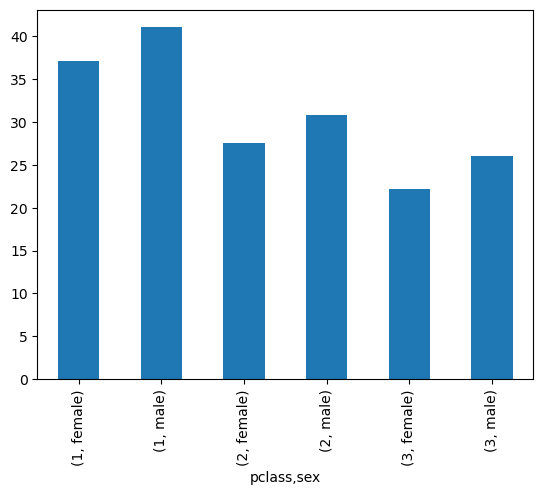

In [70]:
titanic.groupby(["pclass", "sex"])["age"].mean(numeric_only=True).plot(kind="bar")

📈 **Agrupamos por niveles del índice** y calculamos promedios con `groupby()` y `mean(numeric_only=True)`.

In [71]:
titanic.groupby(["pclass", "sex"])["age"].mean(numeric_only=True).unstack()

sex,female,male
pclass,,
1,37.037594,41.029250
2,27.499191,30.815401
3,22.185307,25.962273


📈 **Agrupamos por niveles del índice** y calculamos promedios con `groupby()` y `mean(numeric_only=True)`.

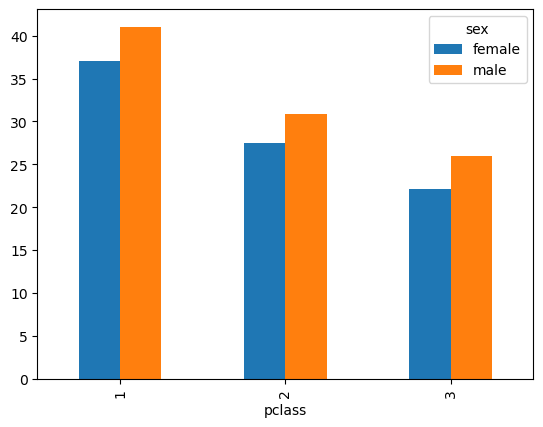

In [72]:
titanic.groupby(["pclass", "sex"])["age"].mean(numeric_only=True).unstack().plot(kind="bar")

📈 **Agrupamos por niveles del índice** y calculamos promedios con `groupby()` y `mean(numeric_only=True)`.

In [73]:
titanic.groupby(["pclass", "sex"])["age"].mean(numeric_only=True).unstack(level="pclass")

pclass,1,2,3
sex,,,
female,37.037594,27.499191,22.185307
male,41.029250,30.815401,25.962273


📈 **Agrupamos por niveles del índice** y calculamos promedios con `groupby()` y `mean(numeric_only=True)`.

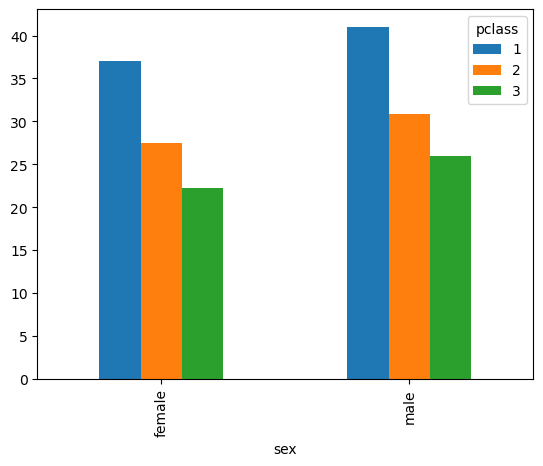

In [74]:
titanic.groupby(["pclass", "sex"])["age"].mean(numeric_only=True).unstack(level="pclass").plot(kind="bar")

📈 **Agrupamos por niveles del índice** y calculamos promedios con `groupby()` y `mean(numeric_only=True)`.

In [75]:
titanic.groupby(["sex", "survived"])["age"].mean(numeric_only=True)

sex     survived
female  0           25.255208
        1           29.815354
male    0           31.516412
        1           26.977778
Name: age, dtype: float64

📈 **Agrupamos por niveles del índice** y calculamos promedios con `groupby()` y `mean(numeric_only=True)`.

In [76]:
titanic.groupby(["sex", "survived"])["age"].mean(numeric_only=True).unstack()

survived,0,1
sex,,
female,25.255208,29.815354
male,31.516412,26.977778


📈 **Agrupamos por niveles del índice** y calculamos promedios con `groupby()` y `mean(numeric_only=True)`.

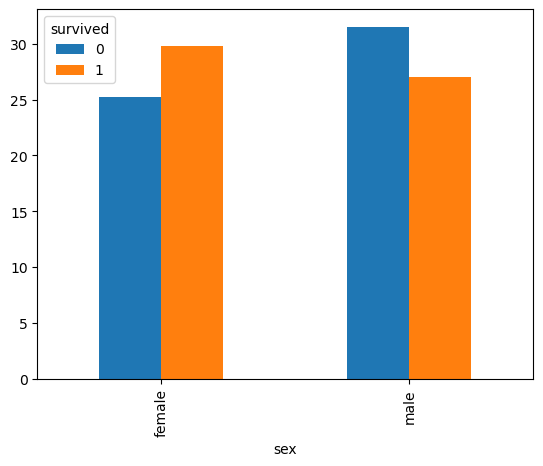

In [77]:
titanic.groupby(["sex", "survived"])["age"].mean(numeric_only=True).unstack().plot(kind="bar")

📈 **Agrupamos por niveles del índice** y calculamos promedios con `groupby()` y `mean(numeric_only=True)`.

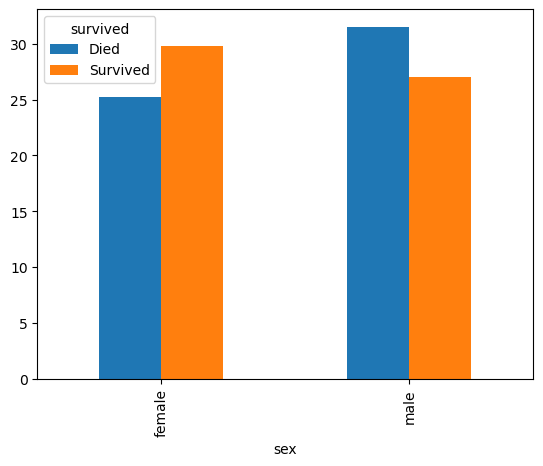

In [78]:
df = titanic.groupby(["sex", "survived"])["age"].mean(numeric_only=True)
df.unstack().rename(columns={0: "Died", 1: "Survived"}).plot(kind="bar")

In [79]:
pops.groupby(level=1).sum()

,population
year,
1990,499245628.0
1991,505961884.0
1992,513028462.0
1993,519837190.0
1994,526251652.0
1995,532556806.0
1996,538788582.0
1997,545293864.0
1998,551708232.0


In [80]:
pops.groupby(level=0).min()

,population
state,
AK,553290.0
AL,4050055.0
AR,2356586.0
AZ,3684097.0
CA,29959515.0
CO,3307618.0
CT,3291967.0
DC,565232.0
DE,669567.0


In [81]:
pops.groupby(level=[1,0]).min()

population
year state            
1990 AK       553290.0
     AL      4050055.0
     AR      2356586.0
     AZ      3684097.0
     CA     29959515.0
...                ...
2013 VT       626630.0
     WA      6971406.0
     WI      5742713.0
     WV      1854304.0
     WY       582658.0

[1272 rows x 1 columns]

In [82]:
pops.index

MultiIndex([('AK', 1990),
            ('AK', 1991),
            ('AK', 1992),
            ('AK', 1993),
            ('AK', 1994),
            ('AK', 1995),
            ('AK', 1996),
            ('AK', 1997),
            ('AK', 1998),
            ('AK', 1999),
            ...
            ('WY', 2004),
            ('WY', 2005),
            ('WY', 2006),
            ('WY', 2007),
            ('WY', 2008),
            ('WY', 2009),
            ('WY', 2010),
            ('WY', 2011),
            ('WY', 2012),
            ('WY', 2013)],
           names=['state', 'year'], length=1272)

In [83]:
pops.groupby(["year", "state"]).min()

population
year state            
1990 AK       553290.0
     AL      4050055.0
     AR      2356586.0
     AZ      3684097.0
     CA     29959515.0
...                ...
2013 VT       626630.0
     WA      6971406.0
     WI      5742713.0
     WV      1854304.0
     WY       582658.0

[1272 rows x 1 columns]